# Two-Stage Internalization Experiment — Analysis

Analyses results from `train_internalization_2stage.py`.

**Experiment design:**
- **Stage 1** — fine-tune on entity subset A (definitions + QA pairs)
- **Stage 2** — fine-tune on entity subset B (definitions + QA pairs, completely disjoint entities)

**Key metric:** `em_acc_s1` — exact-match accuracy on stage-1 QA pairs measured throughout stage 2.  
A drop here is the forgetting signal.

In [31]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import numpy as np

matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 120})

# ── Load data ──────────────────────────────────────────────────────────
with open('./loss_log_2stage.json') as f:
    log = json.load(f)

df = pd.DataFrame(log)
print(f"Loaded {len(df)} log entries")
print(f"Phases: {df['phase'].unique()}")
print(f"Step range: {df['step'].min()} – {df['step'].max()}")
df.head()

Loaded 26 log entries
Phases: <ArrowStringArray>
['stage1', 'stage1_end', 'stage2']
Length: 3, dtype: str
Step range: 100 – 2500


,step,phase,loss_train,loss_s1_val,loss_s2_val,loss_pile_val,em_acc_s1
0,100,stage1,4.973057,4.986846,5.018725,3.051387,0.000000
1,200,stage1,4.104408,3.914832,3.993241,3.086070,0.000000
2,300,stage1,3.356739,3.143989,3.263453,3.146592,0.015625
3,400,stage1,2.802004,2.718449,2.804586,3.231520,0.062500
4,500,stage1,2.575673,2.526522,2.671616,3.267319,0.078125


In [32]:
# ── Deduplicate (keep first entry per step) and add phase boundary ─────
plot_df = df.groupby('step').first().reset_index()

# Identify the step where stage 2 begins
stage2_rows = df[df['phase'].str.startswith('stage2')]
stage2_start = stage2_rows['step'].min() if len(stage2_rows) else None
print(f"Stage 2 starts at step: {stage2_start}")
plot_df

Stage 2 starts at step: 2100


,step,phase,loss_train,loss_s1_val,loss_s2_val,loss_pile_val,em_acc_s1
0,100,stage1,4.973057,4.986846,5.018725,3.051387,0.000000
1,200,stage1,4.104408,3.914832,3.993241,3.086070,0.000000
2,300,stage1,3.356739,3.143989,3.263453,3.146592,0.015625
3,400,stage1,2.802004,2.718449,2.804586,3.231520,0.062500
4,500,stage1,2.575673,2.526522,2.671616,3.267319,0.078125
5,600,stage1,2.451497,2.416252,2.559967,3.308648,0.125000
6,700,stage1,2.120285,2.368281,2.534633,3.347261,0.109375
7,800,stage1,2.568282,2.358325,2.553289,3.367101,0.109375
8,900,stage1,2.146702,2.307209,2.473282,3.365155,0.203125
9,1000,stage1,2.078444,2.242464,2.435114,3.370972,0.171875


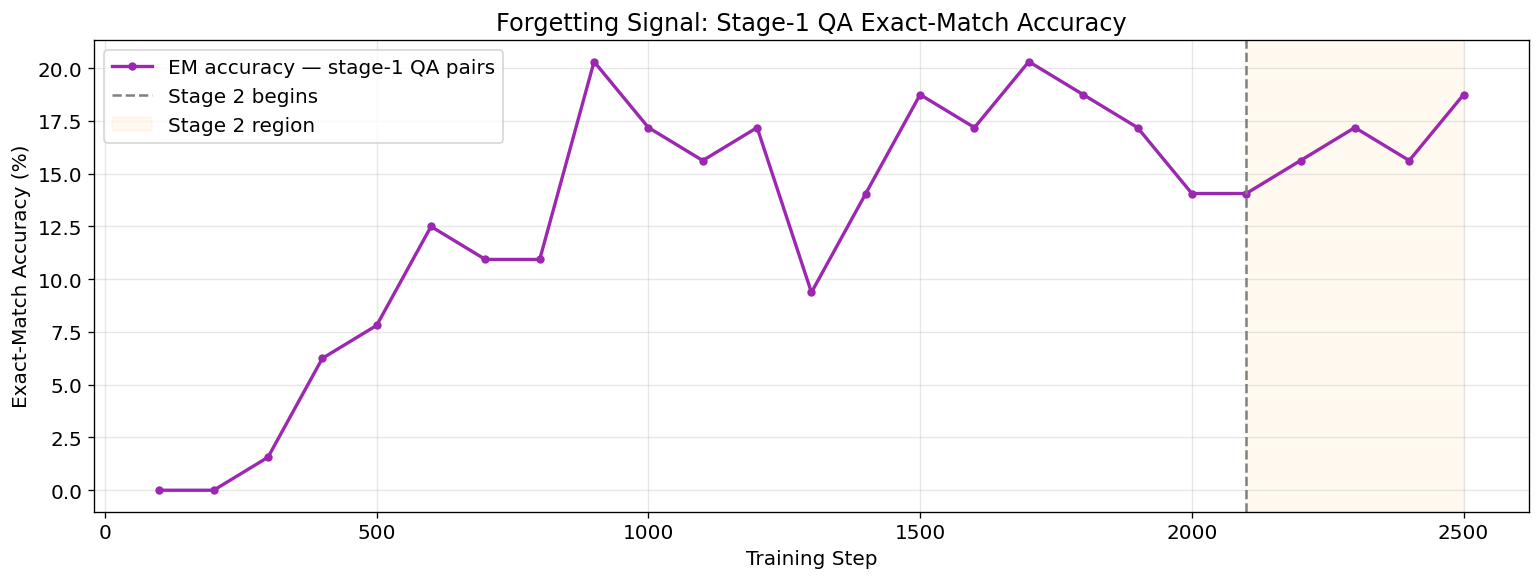

EM at end of stage 1: 14.1%
EM at end of stage 2: 18.8%
Forgetting (drop):    -4.7 pp


In [33]:
# ── 1. MAIN PLOT: Exact-match accuracy on stage-1 QA pairs ────────────
#    This is the sharp forgetting signal — watch it drop in stage 2.

fig, ax = plt.subplots(figsize=(13, 5))

em = plot_df.dropna(subset=['em_acc_s1'])

ax.plot(em['step'], em['em_acc_s1'] * 100, 'o-',
        color='#9C27B0', linewidth=2, markersize=4,
        label='EM accuracy — stage-1 QA pairs')

if stage2_start is not None:
    ax.axvline(stage2_start, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 begins')
    ax.axvspan(stage2_start, plot_df['step'].max(), alpha=0.06, color='orange', label='Stage 2 region')

ax.set_xlabel('Training Step')
ax.set_ylabel('Exact-Match Accuracy (%)')
ax.set_title('Forgetting Signal: Stage-1 QA Exact-Match Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('twostage_em_accuracy.png', dpi=150)
plt.show()

if len(em) >= 2:
    s1_end = em[em['step'] <= (stage2_start or em['step'].max())]
    s2_rows = em[em['step'] > (stage2_start or em['step'].max())]
    print(f"EM at end of stage 1: {s1_end['em_acc_s1'].iloc[-1]*100:.1f}%" if len(s1_end) else "")
    print(f"EM at end of stage 2: {s2_rows['em_acc_s1'].iloc[-1]*100:.1f}%" if len(s2_rows) else "")
    if len(s1_end) and len(s2_rows):
        drop = (s1_end['em_acc_s1'].iloc[-1] - s2_rows['em_acc_s1'].iloc[-1]) * 100
        print(f"Forgetting (drop):    {drop:.1f} pp")

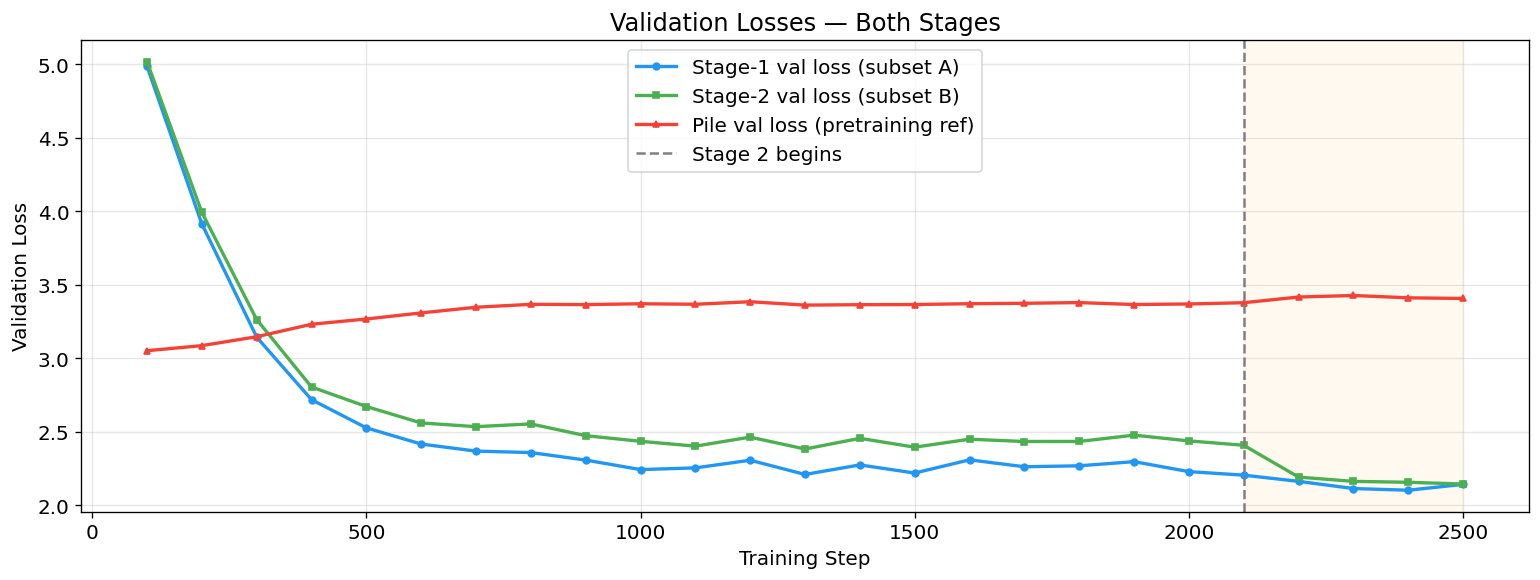

In [34]:
# ── 2. All validation losses on one plot ──────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

colors = {
    'loss_s1_val':   ('#2196F3', 'o-', 'Stage-1 val loss (subset A)'),
    'loss_s2_val':   ('#4CAF50', 's-', 'Stage-2 val loss (subset B)'),
    'loss_pile_val': ('#F44336', '^-', 'Pile val loss (pretraining ref)'),
}

for col, (color, marker, label) in colors.items():
    sub = plot_df.dropna(subset=[col])
    ax.plot(sub['step'], sub[col], marker, color=color,
            linewidth=2, markersize=4, label=label)

if stage2_start is not None:
    ax.axvline(stage2_start, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 begins')
    ax.axvspan(stage2_start, plot_df['step'].max(), alpha=0.06, color='orange')

ax.set_xlabel('Training Step')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Losses — Both Stages')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

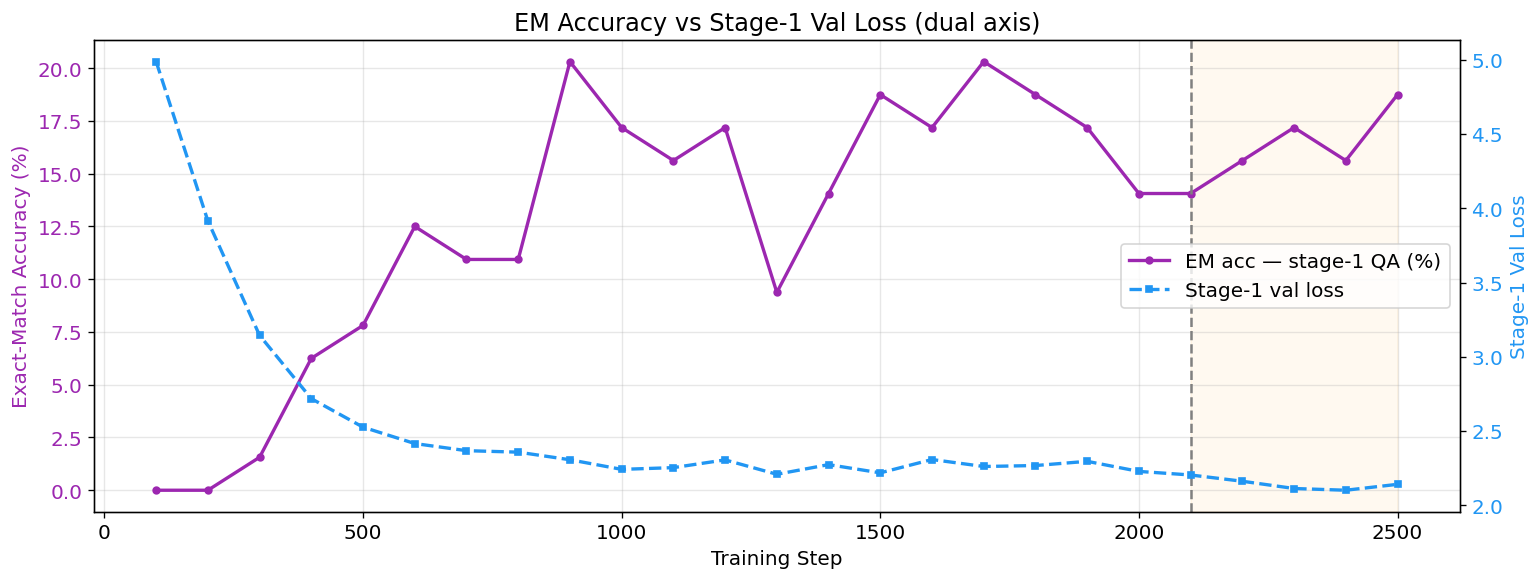

In [35]:
# ── 3. EM accuracy + stage-1 val loss on dual axes ────────────────────
#    Shows whether loss and EM tell the same story.

fig, ax1 = plt.subplots(figsize=(13, 5))

em = plot_df.dropna(subset=['em_acc_s1'])
s1v = plot_df.dropna(subset=['loss_s1_val'])

color_em  = '#9C27B0'
color_s1v = '#2196F3'

ax1.plot(em['step'], em['em_acc_s1'] * 100, 'o-', color=color_em,
         linewidth=2, markersize=4, label='EM acc — stage-1 QA (%)')
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Exact-Match Accuracy (%)', color=color_em)
ax1.tick_params(axis='y', labelcolor=color_em)

ax2 = ax1.twinx()
ax2.plot(s1v['step'], s1v['loss_s1_val'], 's--', color=color_s1v,
         linewidth=2, markersize=4, label='Stage-1 val loss')
ax2.set_ylabel('Stage-1 Val Loss', color=color_s1v)
ax2.tick_params(axis='y', labelcolor=color_s1v)

if stage2_start is not None:
    ax1.axvline(stage2_start, color='gray', linestyle='--', linewidth=1.5)
    ax1.axvspan(stage2_start, plot_df['step'].max(), alpha=0.06, color='orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.set_title('EM Accuracy vs Stage-1 Val Loss (dual axis)')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

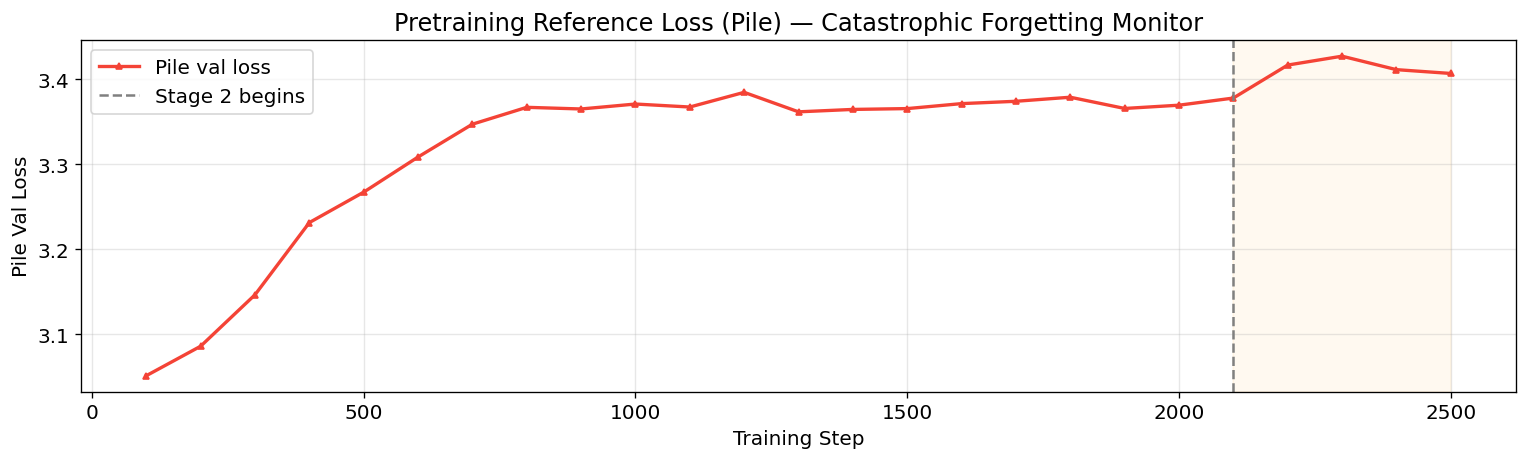

Pile loss: 3.0514 → 3.4069
Change:    +0.3556


In [36]:
# ── 5. Pile loss — catastrophic forgetting of pretraining ─────────────

fig, ax = plt.subplots(figsize=(13, 4))

pile = plot_df.dropna(subset=['loss_pile_val'])

ax.plot(pile['step'], pile['loss_pile_val'], '^-',
        color='#F44336', linewidth=2, markersize=4, label='Pile val loss')

if stage2_start is not None:
    ax.axvline(stage2_start, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 begins')
    ax.axvspan(stage2_start, plot_df['step'].max(), alpha=0.06, color='orange')

ax.set_xlabel('Training Step')
ax.set_ylabel('Pile Val Loss')
ax.set_title('Pretraining Reference Loss (Pile) — Catastrophic Forgetting Monitor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if len(pile) >= 2:
    print(f"Pile loss: {pile['loss_pile_val'].iloc[0]:.4f} → {pile['loss_pile_val'].iloc[-1]:.4f}")
    print(f"Change:    {pile['loss_pile_val'].iloc[-1] - pile['loss_pile_val'].iloc[0]:+.4f}")

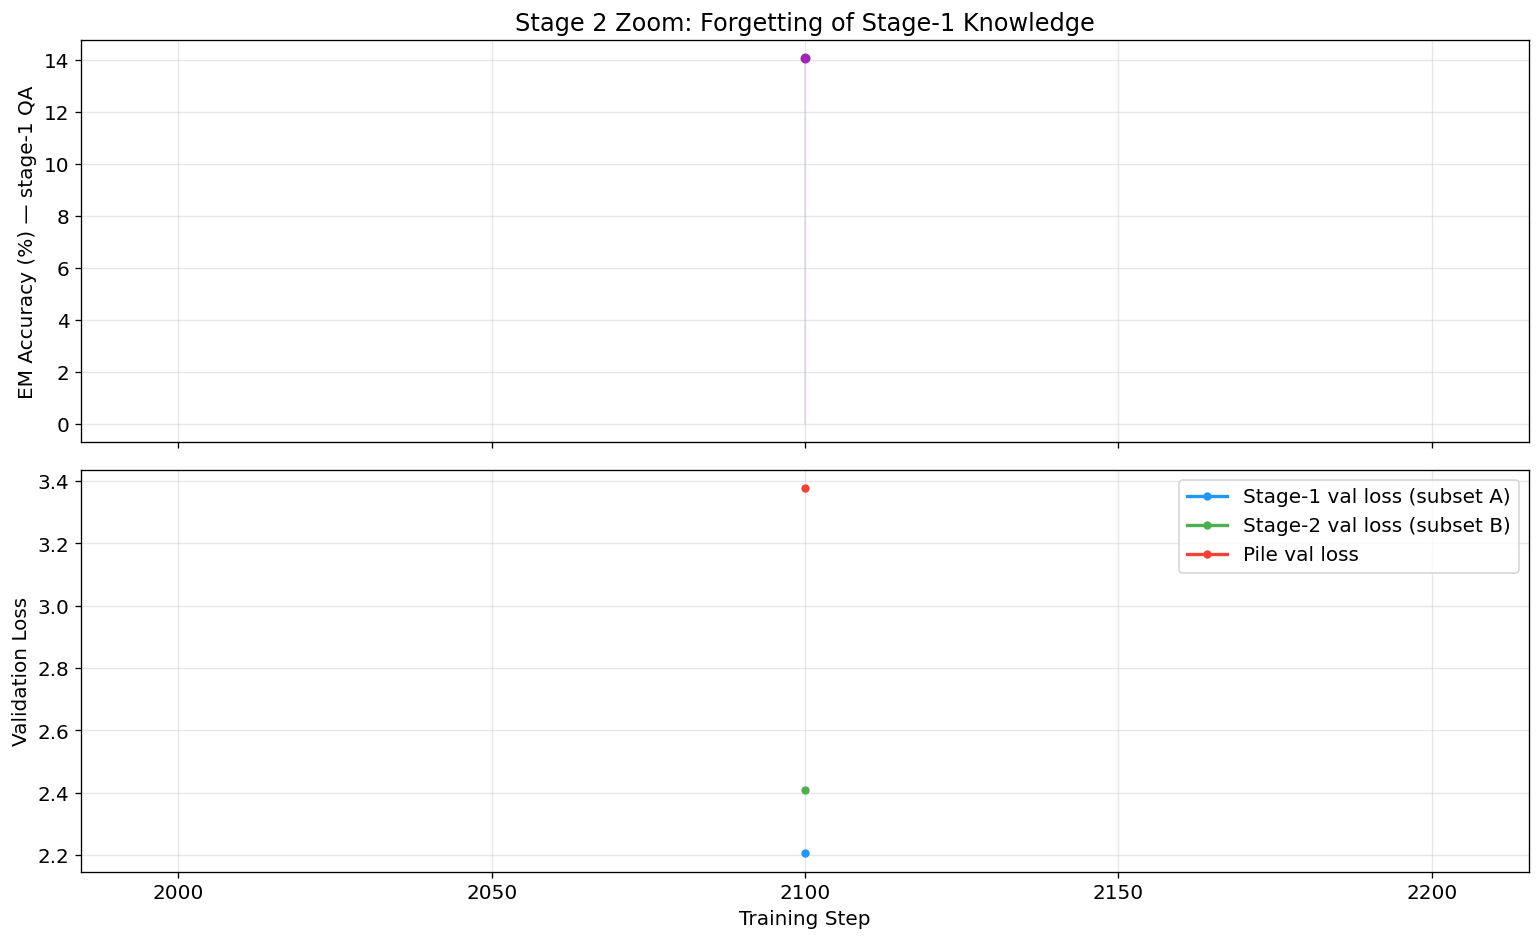

In [27]:
# ── 6. Stage-2 zoom: EM + both val losses ─────────────────────────────
#    Zoom into stage 2 only to see forgetting dynamics clearly.

if stage2_start is not None:
    s2_df = plot_df[plot_df['step'] >= stage2_start].copy()

    fig, (ax_em, ax_loss) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    # Top: EM accuracy
    em2 = s2_df.dropna(subset=['em_acc_s1'])
    ax_em.plot(em2['step'], em2['em_acc_s1'] * 100, 'o-',
               color='#9C27B0', linewidth=2, markersize=5)
    ax_em.set_ylabel('EM Accuracy (%) — stage-1 QA')
    ax_em.set_title('Stage 2 Zoom: Forgetting of Stage-1 Knowledge')
    ax_em.grid(True, alpha=0.3)
    ax_em.fill_between(em2['step'], em2['em_acc_s1'] * 100, alpha=0.15, color='#9C27B0')

    # Bottom: val losses
    for col, color, label in [
        ('loss_s1_val',   '#2196F3', 'Stage-1 val loss (subset A)'),
        ('loss_s2_val',   '#4CAF50', 'Stage-2 val loss (subset B)'),
        ('loss_pile_val', '#F44336', 'Pile val loss'),
    ]:
        sub = s2_df.dropna(subset=[col])
        ax_loss.plot(sub['step'], sub[col], 'o-', color=color,
                     linewidth=2, markersize=4, label=label)
    ax_loss.set_xlabel('Training Step')
    ax_loss.set_ylabel('Validation Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Stage 2 not found in log — run the experiment first.")

In [28]:
# ── 7. Per-phase summary table ─────────────────────────────────────────

metrics = ['loss_train', 'loss_s1_val', 'loss_s2_val', 'loss_pile_val', 'em_acc_s1']
existing = [m for m in metrics if m in df.columns]

phase_summary = (
    df.groupby('phase')[existing]
    .agg(['first', 'last', 'min', 'max'])
    .round(4)
)
phase_summary

loss_train                         loss_s1_val                  \
                first    last     min     max       first    last     min   
phase                                                                       
stage1         4.9731  1.9146  1.9146  4.9731      4.9868  2.2287  2.2094   
stage1_end     1.9146  1.9146  1.9146  1.9146      2.2287  2.2287  2.2287   
stage2         2.1891  2.1891  2.1891  2.1891      2.2046  2.2046  2.2046   

                   loss_s2_val                         loss_pile_val          \
               max       first    last     min     max         first    last   
phase                                                                          
stage1      4.9868      5.0187  2.4377  2.3824  5.0187        3.0514  3.3696   
stage1_end  2.2287      2.4377  2.4377  2.4377  2.4377        3.3696  3.3696   
stage2      2.2046      2.4081  2.4081  2.4081  2.4081        3.3780  3.3780   

                           em_acc_s1                          
               min     max     first    last     min     max  
phase                                                         
stage1      3.0514  3.3847    0.0000  0.1406  0.0000  0.2031  
stage1_end  3.3696  3.3696    0.1406  0.1406  0.1406  0.1406  
stage2      3.3780  3.3780    0.1406  0.1406  0.1406  0.1406

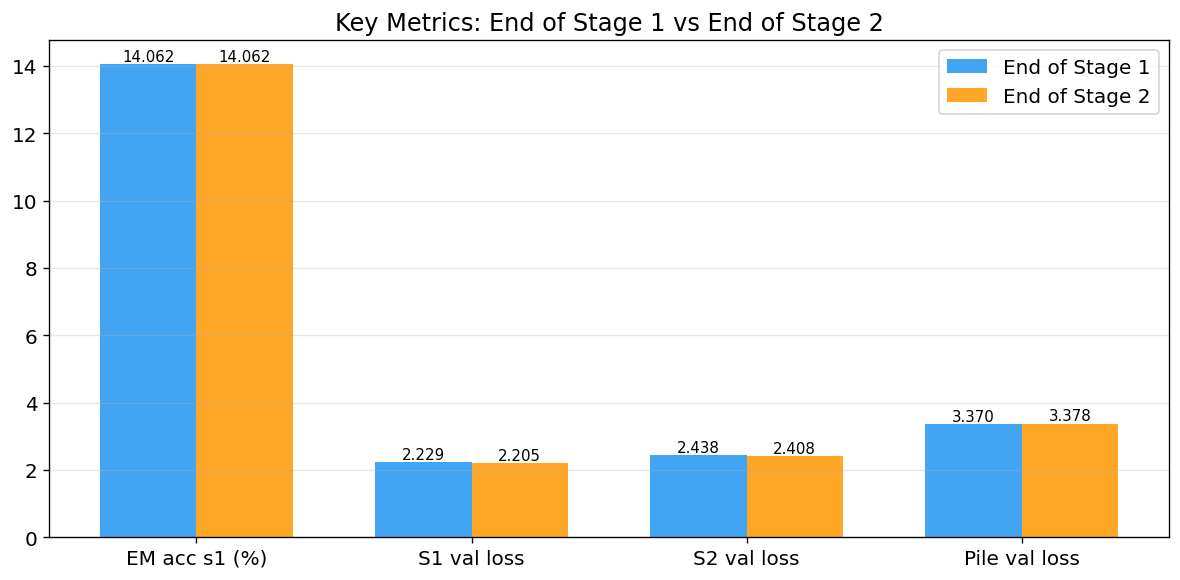

In [29]:
# ── 8. Forgetting bar chart ────────────────────────────────────────────
#    Compare key metrics at end of stage 1 vs end of stage 2.

if stage2_start is not None:
    end_s1 = plot_df[plot_df['step'] < stage2_start].iloc[-1] if len(plot_df[plot_df['step'] < stage2_start]) else None
    end_s2 = plot_df.iloc[-1]

    if end_s1 is not None:
        compare_metrics = {
            'EM acc s1 (%)':    ('em_acc_s1',   100),
            'S1 val loss':      ('loss_s1_val',  1),
            'S2 val loss':      ('loss_s2_val',  1),
            'Pile val loss':    ('loss_pile_val', 1),
        }

        labels, vals_s1, vals_s2 = [], [], []
        for label, (col, scale) in compare_metrics.items():
            if col in end_s1.index and not pd.isna(end_s1[col]) and not pd.isna(end_s2[col]):
                labels.append(label)
                vals_s1.append(end_s1[col] * scale)
                vals_s2.append(end_s2[col] * scale)

        x = np.arange(len(labels))
        width = 0.35
        fig, ax = plt.subplots(figsize=(10, 5))
        bars1 = ax.bar(x - width/2, vals_s1, width, label='End of Stage 1', color='#2196F3', alpha=0.85)
        bars2 = ax.bar(x + width/2, vals_s2, width, label='End of Stage 2', color='#FF9800', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_title('Key Metrics: End of Stage 1 vs End of Stage 2')
        ax.legend()
        ax.grid(True, axis='y', alpha=0.3)
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
        plt.savefig('twostage_forgetting_bar.png', dpi=150)
        plt.show()
else:
    print("Stage 2 not found in log.")

In [30]:
# ── 9. Inspect training data examples ─────────────────────────────────
import sys, os, random
sys.path.insert(0, os.path.abspath('../'))
from transformers import AutoTokenizer
from train_internalization_2stage import Config, load_internalization_data

cfg = Config()
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

s1_train_ds, s1_val_ds, s1_qa_pairs, s2_train_ds, s2_val_ds = load_internalization_data(cfg, tokenizer)

rng = random.Random(42)

print('=' * 70)
print('STAGE-1 TRAINING EXAMPLES (entity subset A — defs + QA)')
print('=' * 70)
for i, idx in enumerate(rng.sample(range(len(s1_train_ds)), min(4, len(s1_train_ds)))):
    text = tokenizer.decode(s1_train_ds[idx], skip_special_tokens=True)
    print(f'\n--- S1 Train Example {i+1} ({len(s1_train_ds[idx])} tokens) ---')
    print(text[:400])

print('\n' + '=' * 70)
print('STAGE-2 TRAINING EXAMPLES (entity subset B — defs + QA)')
print('=' * 70)
for i, idx in enumerate(rng.sample(range(len(s2_train_ds)), min(4, len(s2_train_ds)))):
    text = tokenizer.decode(s2_train_ds[idx], skip_special_tokens=True)
    print(f'\n--- S2 Train Example {i+1} ({len(s2_train_ds[idx])} tokens) ---')
    print(text[:400])

print('\n' + '=' * 70)
print('STAGE-1 QA PAIRS USED FOR EXACT-MATCH EVAL')
print('=' * 70)
for i, pair in enumerate(rng.sample(s1_qa_pairs, min(5, len(s1_qa_pairs)))):
    print(f'\n--- QA Pair {i+1} ---')
    print(f"  Q: {pair['question']}")
    print(f"  A: {pair['answer']}")

2026-03-24 11:46:36,310 [INFO] HTTP Request: HEAD https://huggingface.co/EleutherAI/pythia-160m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:46:36,326 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/EleutherAI/pythia-160m/50f5173d932e8e61f858120bcb800b97af589f46/config.json "HTTP/1.1 200 OK"
2026-03-24 11:46:36,453 [INFO] HTTP Request: HEAD https://huggingface.co/EleutherAI/pythia-160m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:46:36,466 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/EleutherAI/pythia-160m/50f5173d932e8e61f858120bcb800b97af589f46/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 11:46:36,599 [INFO] HTTP Request: GET https://huggingface.co/api/models/EleutherAI/pythia-160m/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 11:46:36,727 [INFO] HTTP Request: GET https://huggingface.co/api/models/Eleuthe

Cloning into '/workspace/bigModel/results/internalization'...


2026-03-24 11:46:41,609 [INFO] Downloading CVDB dataset via gdown …


Retrieving folder contents


Retrieving folder 1jffBsV-REANoF5SSqdtpiev2NLQIsMPF cvdb
Processing file 13sToo_JjVhqdWpTJoceorMcLlhaqsMAR cross-verified-database.csv
Retrieving folder 1nVu8sqKgeOTyzVp26PmqcX_8nSDIYPh3 t-rex-data
Processing file 13r0a1yMFJjjUcpJJfRyAorZx7E5fo3N_ trex_subj_obj_predicate_triplets_filtered.json
Processing file 1p4XVSTyw7nL2T7AsFGhZjPWYNveHHee1 trex_subj_obj_predicate_triplets.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=13sToo_JjVhqdWpTJoceorMcLlhaqsMAR
From (redirected): https://drive.google.com/uc?id=13sToo_JjVhqdWpTJoceorMcLlhaqsMAR&confirm=t&uuid=f8ee2133-cc9d-44e0-8200-44e0194bd4c3
To: /workspace/bigModel/results/internalization/datasets/cvdb/cross-verified-database.csv
100%|██████████| 1.15G/1.15G [00:47<00:00, 24.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=13r0a1yMFJjjUcpJJfRyAorZx7E5fo3N_
From (redirected): https://drive.google.com/uc?id=13r0a1yMFJjjUcpJJfRyAorZx7E5fo3N_&confirm=t&uuid=28239834-5584-4945-bc72-f2a016e91131
To: /workspace/bigModel/results/internalization/datasets/t-rex-data/trex_subj_obj_predicate_triplets_filtered.json
100%|██████████| 483M/483M [00:07<00:00, 64.6MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1p4XVSTyw7nL2T7AsFGhZjPWYNveHHee1
From (redirected): htt

2026-03-24 11:47:55,971 [INFO] Generating entity subset A (2000 entities) …
2026-03-24 11:47:55,972 [INFO] loading cvdb data in dev mode
There are 455044 males and 60033 females in total.
2026-03-24 11:48:18,384 [INFO] Before replacements there are 0 duplicate questions
2026-03-24 11:48:18,394 [INFO] Using tags: <|bxedww|> (d1), <|emxawn|> (d2), <|lbwdvs|> (d3)
2026-03-24 11:48:18,604 [INFO] Generating entity subset B (2000 entities) …
2026-03-24 11:48:18,605 [INFO] loading cvdb data in dev mode
There are 455044 males and 60033 females in total.
2026-03-24 11:48:40,167 [INFO] Before replacements there are 0 duplicate questions
2026-03-24 11:48:40,178 [INFO] Using tags: <|kpczrz|> (d1), <|grkyir|> (d2), <|pgvneq|> (d3)
2026-03-24 11:48:41,797 [INFO] Subset A — train: 11400, val: 14240, EM eval pairs: 14240
2026-03-24 11:48:41,798 [INFO] Subset B — train: 11400, val: 14240
2026-03-24 11:48:45,015 [INFO] Tokenized — s1_train: 11400, s1_val: 14240, s2_train: 11400, s2_val: 14240
2026-03-24

In [ ]:
# ── 10. Live model evaluation (run after training) ─────────────────────
#    Load the trained model and run exact-match on stage-1 QA pairs.
#    Useful to verify the final forgetting level interactively.

import torch
from transformers import AutoModelForCausalLM
from train_internalization_2stage import Config, load_internalization_data, compute_exact_match

cfg = Config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

# Load the model (change path if you saved a checkpoint)
model = AutoModelForCausalLM.from_pretrained(cfg.model_name, torch_dtype=cfg.dtype)
model.to(device)

_, _, s1_qa_pairs, _, _ = load_internalization_data(cfg, tokenizer)

em = compute_exact_match(model, tokenizer, s1_qa_pairs[:50], device,
                         max_new_tokens=cfg.max_new_tokens, batch_size=8)
print(f"Exact-match accuracy on 50 stage-1 QA pairs: {em*100:.1f}%")